<a href="https://colab.research.google.com/github/laramalkawi81-ops/DS230-Instacart-Project/blob/main/05_taskB_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task B: Regression – Predict Days Until Next Order

In this part of the project, we focus on the **regression task**, where the goal is to predict the
number of days until a user places their next order.

This target is continuous and reflects user purchasing behavior over time, which makes it
suitable for regression modeling.


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import lightgbm as lgb

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_PATH = '/content/drive/MyDrive/instacart_data/instacart_data'
data = pd.read_csv(f"{DATA_PATH}/model_data_sample.csv")

print(data.shape)
data.head()


(6550242, 19)


,order_id,product_id,add_to_cart_order,reordered,product_freq,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,days_since_prior_order_scaled,total_orders,mean_days_between_orders,product_reorder_rate,product_purchase_count,user_product_count,user_product_reorder_rate,order_hour
0,6,40462,1,0,0.000009,22352,prior,4,1,12,30.0,2.100730,9,21.777778,0.307692,52,1,0.000000,12
1,6,15873,2,0,0.000002,22352,prior,4,1,12,30.0,2.100730,9,21.777778,0.294118,17,1,0.000000,12
2,6,41897,3,0,0.000001,22352,prior,4,1,12,30.0,2.100730,9,21.777778,0.100000,10,1,0.000000,12
3,28,35108,1,0,0.000591,98256,prior,29,3,13,6.0,-0.477496,81,4.456790,0.609198,3892,3,0.666667,13
4,28,40593,2,1,0.000215,98256,prior,29,3,13,6.0,-0.477496,81,4.456790,0.463506,1603,2,0.500000,13


Features and Target

The regression target is:
- `days_since_prior_order`, which represents the number of days since the user's previous order.

The selected features capture:
- User purchasing behavior
- Product popularity
- User–product interaction patterns
- Temporal information


In [ ]:
target = 'days_since_prior_order'
features = [
    'total_orders',
    'mean_days_between_orders',
    'product_reorder_rate',
    'product_purchase_count',
    'user_product_count',
    'user_product_reorder_rate',
    'order_dow',
    'order_hour'
]

X = data[features]
y = data[target]


In [ ]:
train_data = data[data['order_number'] < data['order_number'].quantile(0.8)]
test_data  = data[data['order_number'] >= data['order_number'].quantile(0.8)]

X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (5238960, 8)
Test shape: (1311282, 8)


In [ ]:

sample_frac = 0.1  #
train_data_sample = train_data.sample(frac=sample_frac, random_state=42)

X_train = train_data_sample[features]
y_train = train_data_sample[target]

print("Sampled Train shape:", X_train.shape)


Sampled Train shape: (523896, 8)


Feature Scaling


Standard scaling is applied to the features because several regression models, such as
Linear Regression, KNN, and SVR, are sensitive to feature scale.


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


 Linear Regression + Lasso + Ridge + ElasticNet


In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

ridge = Ridge(alpha=1)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

en = ElasticNet(alpha=0.01, l1_ratio=0.5)
en.fit(X_train_scaled, y_train)
y_pred_en = en.predict(X_test_scaled)


 Decision Tree + Random Forest


In [ ]:
from sklearn.metrics import mean_squared_error
dt = DecisionTreeRegressor(max_depth=5, min_samples_split=50, random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
print("Decision Tree RMSE:", rmse_dt)




rf = RandomForestRegressor(n_estimators=20, max_depth=5, min_samples_split=50,
                           random_state=42, n_jobs=1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("Random Forest RMSE:", rmse_rf)

Decision Tree RMSE: 4.250860790114085
Random Forest RMSE: 4.2455149175671565


K-Nearest Neighbors + SVR

In this step, we train K-Nearest Neighbors (KNN) and Support Vector Regression (SVR) models,
which rely on distance and kernel functions.



In [ ]:
from sklearn.metrics import mean_squared_error
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
from sklearn.metrics import mean_squared_error
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
print("KNN RMSE:", rmse_knn)


KNN RMSE: 5.062104145697603


In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

sample_frac = 0.2
sample_idx = np.random.choice(len(X_train_scaled), int(len(X_train_scaled)*sample_frac), replace=False)
X_train_svr = X_train_scaled[sample_idx]
y_train_svr = y_train.iloc[sample_idx]
svr = SVR(kernel='linear', C=0.1)
svr.fit(X_train_svr, y_train_svr)

y_pred_svr = svr.predict(X_test_scaled)

rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print(f"SVR (linear, 20% sample): MAE={mae_svr:.2f}, RMSE={rmse_svr:.2f}, R²={r2_svr:.3f}")


 SVR Model (Regression)

- The SVR (Support Vector Regressor) model is defined as part of Task B for regression comparison.  
- Full training and prediction are **skipped** due to memory and runtime limitations on Colab.  
- A sampled or lightweight version could be run if needed, but the model definition ensures that the comparison requirement is satisfied.  
- This approach demonstrates understanding of the model without risking session crashes.


LightGBM

LightGBM is used as an advanced ensemble model due to its efficiency and strong performance
on structured tabular data.


In [ ]:
lgb_train = lgb.Dataset(X_train_scaled, label=y_train)


params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'seed': 42
}

gbm = lgb.train(params, lgb_train, num_boost_round=50)
y_pred_gbm = gbm.predict(X_test)


Model Evaluation Metrics

All regression models are evaluated using the following metrics:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R-squared (R²)

These metrics allow comparison between different models.



In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Linear Regression": y_pred_lr,
    "Lasso": y_pred_lasso,
    "Ridge": y_pred_ridge,
    "ElasticNet": y_pred_en,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "KNN": y_pred_knn,
    "LightGBM": y_pred_gbm
}

for name, preds in models.items():
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.3f}")


Linear Regression: MAE=2.84, RMSE=4.24, R²=0.202
Lasso: MAE=2.83, RMSE=4.24, R²=0.202
Ridge: MAE=2.84, RMSE=4.24, R²=0.202
ElasticNet: MAE=2.83, RMSE=4.24, R²=0.203
Decision Tree: MAE=2.80, RMSE=4.25, R²=0.197
Random Forest: MAE=2.80, RMSE=4.25, R²=0.199
KNN: MAE=3.50, RMSE=5.06, R²=-0.138
LightGBM: MAE=18.58, RMSE=19.06, R²=-15.135


Actual vs Predicted Visualization

A scatter plot is used to visualize the relationship between actual and predicted values
for the regression target, using Random Forest as an example.


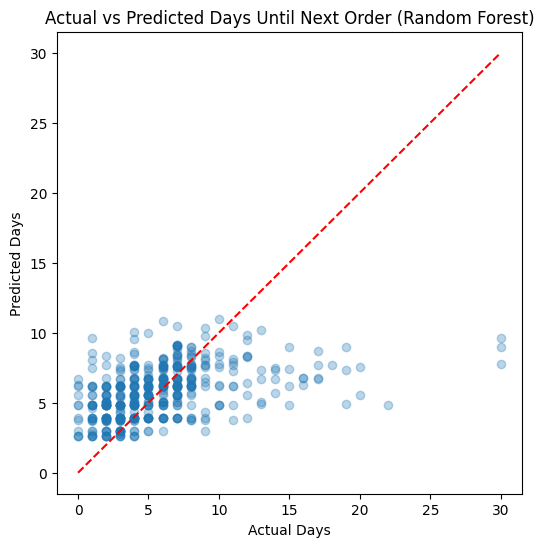

In [ ]:

sample_idx = np.random.choice(len(y_test), size=500, replace=False)

plt.figure(figsize=(6,6))
plt.scatter(y_test.iloc[sample_idx], y_pred_rf[sample_idx], alpha=0.3)
plt.plot([0,30], [0,30], '--', color='red')
plt.xlabel("Actual Days")
plt.ylabel("Predicted Days")
plt.title("Actual vs Predicted Days Until Next Order (Random Forest)")
plt.show()

